# Implementasi Knowledge Distillation: ResNet-50 → MobileNetV3-Small

**Dataset:** Breast Ultrasound Images (BUSI)  
**Metode:** Knowledge Distillation (KD) dengan grid search hyperparameter T dan α

---

### Alur Eksekusi
1. Install dependensi
2. Download dataset BUSI dari Kaggle
3. Latih Teacher (ResNet-50)
4. Grid Search hyperparameter KD → Latih Student (MobileNetV3-Small)
5. Evaluasi & visualisasi

## 1. Install Dependensi

In [ ]:
!pip install torch torchvision scikit-learn scipy matplotlib seaborn scikit-image kaggle tqdm

## 2. Download Dataset BUSI dari Kaggle

Dataset: [Breast Ultrasound Images Dataset](https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset)

**Prasyarat:** Siapkan Kaggle API key (`kaggle.json`):
1. Login ke [kaggle.com](https://www.kaggle.com) → Account → Create New API Token
2. Simpan file `kaggle.json` di direktori ini, **atau** letakkan di `~/.kaggle/kaggle.json`
3. Jalankan cell di bawah

In [23]:
import os
import shutil
import zipfile

# ─── Konfigurasi path ───────────────────────────────────────────────────────
KAGGLE_JSON_PATH = "kaggle.json"           # Ubah jika kaggle.json ada di tempat lain
DATA_DIR         = "data/BUSI"             # Direktori tujuan dataset
DATASET_SLUG     = "aryashah2k/breast-ultrasound-images-dataset"
ZIP_NAME         = "breast-ultrasound-images-dataset.zip"
EXTRACTED_SUBDIR = "Dataset_BUSI_with_GT"  # Subfolder di dalam ZIP
# ────────────────────────────────────────────────────────────────────────────

# Salin kaggle.json ke ~/.kaggle/ jika belum ada
kaggle_dir = os.path.expanduser("~/.kaggle")
kaggle_cfg = os.path.join(kaggle_dir, "kaggle.json")
if not os.path.exists(kaggle_cfg):
    if os.path.exists(KAGGLE_JSON_PATH):
        os.makedirs(kaggle_dir, exist_ok=True)
        shutil.copy(KAGGLE_JSON_PATH, kaggle_cfg)
        os.chmod(kaggle_cfg, 0o600)
        print("kaggle.json disalin ke ~/.kaggle/")
    else:
        print("[ERROR] kaggle.json tidak ditemukan.")
        print("Letakkan kaggle.json di direktori ini atau di ~/.kaggle/kaggle.json")
        raise FileNotFoundError("kaggle.json tidak ditemukan")
else:
    print("Kaggle credentials sudah ada.")

# Download dataset
os.makedirs(DATA_DIR, exist_ok=True)
if not os.path.exists(os.path.join(DATA_DIR, EXTRACTED_SUBDIR)):
    print(f"Mengunduh dataset '{DATASET_SLUG}'...")
    !kaggle datasets download -d {DATASET_SLUG} -p {DATA_DIR}

    zip_path = os.path.join(DATA_DIR, ZIP_NAME)
    print("Mengekstrak dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(DATA_DIR)
    os.remove(zip_path)
    print("Dataset berhasil diekstrak.")
else:
    print("Dataset sudah tersedia, melewati download.")

# Root directory yang akan dipakai sepanjang notebook
ROOT_DIR = os.path.join(DATA_DIR, EXTRACTED_SUBDIR)
print(f"\nROOT_DIR = {ROOT_DIR}")

Kaggle credentials sudah ada.
Dataset sudah tersedia, melewati download.

ROOT_DIR = data/BUSI/Dataset_BUSI_with_GT


In [24]:
# Verifikasi struktur dataset
for cls in ["benign", "malignant", "normal"]:
    cls_dir = os.path.join(ROOT_DIR, cls)
    imgs    = [f for f in os.listdir(cls_dir) if f.endswith(".png") and "mask" not in f]
    print(f"  {cls:12s}: {len(imgs):4d} gambar")

  benign      :  437 gambar
  malignant   :  210 gambar
  normal      :  133 gambar


## 3. Imports & Konfigurasi Global

In [25]:
import os
import time
import numpy as np
from PIL import Image
from skimage.restoration import denoise_tv_chambolle

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)
from scipy.stats import wilcoxon

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# ─── Deteksi device: CUDA → MPS (Apple Silicon) → CPU ─────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")       # ← M1 / M2 / M3 / M4 GPU via Metal
else:
    DEVICE = torch.device("cpu")

# ─── Konfigurasi global ────────────────────────────────────────────────────
NUM_CLASSES  = 3
CLASS_MAP    = {"benign": 0, "malignant": 1, "normal": 2}
CLASS_NAMES  = ["Benign", "Malignant", "Normal"]
BATCH_SIZE   = 16
SEED         = 42
SEEDS        = [0, 1, 2, 3, 4]
NUM_WORKERS  = 0   # Harus 0 di macOS Jupyter (multiprocessing fork issue)

os.makedirs("checkpoints", exist_ok=True)

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
print(f"MPS avail: {torch.backends.mps.is_available()}")
print(f"MPS built: {torch.backends.mps.is_built()}")

# Sanity check – operasi tensor kecil di device terpilih
_x = torch.randn(4, 4).to(DEVICE)
print(f"Tensor test: {(_x @ _x.T).shape} on {_x.device} ✓")
del _x

PyTorch  : 2.9.1
Device   : mps
MPS avail: True
MPS built: True
Tensor test: torch.Size([4, 4]) on mps:0 ✓


In [26]:
# ─── Mini-benchmark: MPS vs CPU ───────────────────────────────────────────
# Membandingkan kecepatan forward pass ResNet-50 dummy di MPS vs CPU
import time

def _bench(device_name, n=20):
    dev   = torch.device(device_name)
    model = models.resnet50(weights=None).to(dev).eval()
    x     = torch.randn(4, 3, 224, 224).to(dev)
    # warm-up
    with torch.no_grad():
        for _ in range(3):
            model(x)
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(n):
            model(x)
    return (time.perf_counter() - t0) / n * 1000   # ms per batch

print("Benchmark forward pass ResNet-50 (batch=4, 224×224) ...")
cpu_ms = _bench("cpu")
print(f"  CPU : {cpu_ms:7.1f} ms / batch")

if torch.backends.mps.is_available():
    mps_ms = _bench("mps")
    print(f"  MPS : {mps_ms:7.1f} ms / batch")
    print(f"  Speedup MPS vs CPU: {cpu_ms/mps_ms:.2f}×")

print(f"\n→ Training akan berjalan di: {DEVICE}")

Benchmark forward pass ResNet-50 (batch=4, 224×224) ...
  CPU :    65.8 ms / batch
  MPS :    25.1 ms / batch
  Speedup MPS vs CPU: 2.62×

→ Training akan berjalan di: mps


## 4. Modul Dataset

## 4. Pre-Cache Denoised Images (Wajib untuk Efisiensi)

> **Mengapa penting?**  
> `denoise_tv_chambolle` memakan ~180 ms per gambar di CPU.  
> Tanpa cache: **~7 jam** untuk grid search.  
> Dengan cache (run sekali): **~35–50 menit** untuk grid search.  
>
> Cell berikut memproses semua gambar sekali dan menyimpannya ke `data/BUSI_denoised/`.

In [27]:
from concurrent.futures import ThreadPoolExecutor, as_completed

CACHE_DIR = "data/BUSI_denoised"   # direktori hasil cache

def _denoise_and_save(src_path, dst_path):
    """Denoise 1 gambar dan simpan ke dst_path."""
    if os.path.exists(dst_path):
        return dst_path, True   # sudah ada, skip
    img    = Image.open(src_path).convert("RGB")
    arr    = np.array(img).astype(np.float32) / 255.0
    dn     = denoise_tv_chambolle(arr, weight=0.1, channel_axis=-1)
    Image.fromarray((dn * 255).astype(np.uint8)).save(dst_path)
    return dst_path, False

def build_denoise_cache(root_dir, cache_dir, n_workers=None):
    """
    Pre-denoise semua gambar dan simpan ke cache_dir.
    Menggunakan ThreadPoolExecutor (kompatibel dengan Jupyter/macOS).
    denoise_tv_chambolle adalah C extension → melepas GIL → paralel nyata.
    """
    if n_workers is None:
        import multiprocessing
        n_workers = max(1, multiprocessing.cpu_count() - 1)

    # Kumpulkan semua task (src → dst)
    tasks = []
    for cls_name in CLASS_MAP:
        src_cls = os.path.join(root_dir, cls_name)
        dst_cls = os.path.join(cache_dir, cls_name)
        os.makedirs(dst_cls, exist_ok=True)
        for fname in sorted(os.listdir(src_cls)):
            if fname.endswith(".png"):
                tasks.append((
                    os.path.join(src_cls, fname),
                    os.path.join(dst_cls, fname),
                ))

    already_done = sum(1 for _, dst in tasks if os.path.exists(dst))
    remaining    = len(tasks) - already_done

    if remaining == 0:
        print(f"✓ Cache sudah lengkap ({already_done} file) di: {cache_dir}")
        return

    print(f"Pre-caching {remaining} gambar dengan {n_workers} thread(s)...")
    print("(Proses ini hanya perlu dijalankan SEKALI)\n")

    t0  = time.perf_counter()
    bar = tqdm(total=len(tasks), desc="Denoising", unit="img")

    with ThreadPoolExecutor(max_workers=n_workers) as exe:
        futures = {exe.submit(_denoise_and_save, src, dst): (src, dst)
                   for src, dst in tasks}
        for fut in as_completed(futures):
            _, skipped = fut.result()
            bar.update(1)
            if not skipped:
                elapsed = time.perf_counter() - t0
                done    = bar.n
                eta     = elapsed / done * (len(tasks) - done) if done else 0
                bar.set_postfix(elapsed=f"{elapsed:.0f}s", ETA=f"{eta:.0f}s")

    bar.close()
    total_s = time.perf_counter() - t0
    print(f"\n✓ Cache selesai dalam {total_s:.0f} detik  →  {cache_dir}")

# ── Jalankan ──────────────────────────────────────────────────────────────
build_denoise_cache(ROOT_DIR, CACHE_DIR)
CACHE_ROOT = CACHE_DIR   # digunakan oleh get_dataloaders

Pre-caching 1578 gambar dengan 9 thread(s)...
(Proses ini hanya perlu dijalankan SEKALI)



Denoising:   0%|          | 0/1578 [00:00<?, ?img/s]


✓ Cache selesai dalam 448 detik  →  data/BUSI_denoised


In [28]:
def load_paths_labels(root_dir):
    paths, labels = [], []
    for cls_name, cls_idx in CLASS_MAP.items():
        cls_dir = os.path.join(root_dir, cls_name)
        for fname in sorted(os.listdir(cls_dir)):
            if fname.endswith(".png") and "mask" not in fname:
                paths.append(os.path.join(cls_dir, fname))
                labels.append(cls_idx)
    return paths, labels


def speckle_reduce(img_array):
    """TV Chambolle denoising – hanya dipakai jika cache belum tersedia."""
    img_float = img_array.astype(np.float32) / 255.0
    denoised  = denoise_tv_chambolle(img_float, weight=0.1, channel_axis=-1)
    return (denoised * 255).astype(np.uint8)


class BUSIDataset(Dataset):
    def __init__(self, paths, labels, transform=None, apply_denoise=True):
        self.paths         = paths
        self.labels        = labels
        self.transform     = transform
        # apply_denoise=False jika gambar sudah pre-denoised (dari cache)
        self.apply_denoise = apply_denoise

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.apply_denoise:
            img = Image.fromarray(speckle_reduce(np.array(img)))
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


def get_transforms(is_train=True):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    if is_train:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])


def get_dataloaders(root_dir, batch_size=BATCH_SIZE, seed=SEED,
                    num_workers=NUM_WORKERS, use_cache=True):
    """
    use_cache=True  → pakai gambar dari CACHE_ROOT (sudah pre-denoised, apply_denoise=False)
    use_cache=False → proses denoise on-the-fly (lambat, fallback)
    """
    src_dir      = CACHE_ROOT if (use_cache and os.path.isdir(CACHE_ROOT)) else root_dir
    do_denoise   = not (use_cache and os.path.isdir(CACHE_ROOT))

    if do_denoise:
        print("⚠ Cache tidak ditemukan, denoise akan dijalankan on-the-fly (lambat).")

    paths, labels = load_paths_labels(src_dir)

    idx = list(range(len(paths)))
    idx_train, idx_temp, y_train, y_temp = train_test_split(
        idx, labels, test_size=0.30, stratify=labels, random_state=seed
    )
    idx_val, idx_test, _, _ = train_test_split(
        idx_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=seed
    )

    def make_subset(indices, is_train):
        p = [paths[i] for i in indices]
        l = [labels[i] for i in indices]
        return BUSIDataset(p, l, transform=get_transforms(is_train),
                           apply_denoise=do_denoise)

    train_ds = make_subset(idx_train, True)
    val_ds   = make_subset(idx_val,   False)
    test_ds  = make_subset(idx_test,  False)

    loader_kwargs = dict(batch_size=batch_size, num_workers=num_workers, pin_memory=False)
    return (
        DataLoader(train_ds, shuffle=True,  **loader_kwargs),
        DataLoader(val_ds,   shuffle=False, **loader_kwargs),
        DataLoader(test_ds,  shuffle=False, **loader_kwargs),
    )


# Buat dataloader (otomatis pakai cache jika tersedia)
train_loader, val_loader, test_loader = get_dataloaders(ROOT_DIR)
print(f"Train : {len(train_loader.dataset):4d} sampel")
print(f"Val   : {len(val_loader.dataset):4d} sampel")
print(f"Test  : {len(test_loader.dataset):4d} sampel")
print(f"Denoise on-the-fly: {train_loader.dataset.apply_denoise}  (False = pakai cache ✓)")

Train :  546 sampel
Val   :  117 sampel
Test  :  117 sampel
Denoise on-the-fly: False  (False = pakai cache ✓)


## 5. Definisi Model

In [29]:
def get_teacher():
    """ResNet-50 pretrained ImageNet, head diganti untuk NUM_CLASSES kelas."""
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model


def get_student():
    """MobileNetV3-Small pretrained ImageNet, head diganti untuk NUM_CLASSES kelas."""
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, NUM_CLASSES)
    return model


def count_params(model):
    return sum(p.numel() for p in model.parameters()) / 1e6


# Info parameter
_t = get_teacher()
_s = get_student()
print(f"Teacher (ResNet-50)       : {count_params(_t):.2f} M parameter")
print(f"Student (MobileNetV3-Sm.) : {count_params(_s):.2f} M parameter")
del _t, _s

Teacher (ResNet-50)       : 23.51 M parameter
Student (MobileNetV3-Sm.) : 1.52 M parameter


## 6. Latih Teacher (ResNet-50)

- 10 epoch pertama: hanya `fc` layer yang dilatih (feature extractor dibekukan)
- Setelah epoch ke-10: semua layer dibuka (*unfreezing*)
- Early stopping dengan patience 15 epoch

In [30]:
def unfreeze_schedule(model, epoch):
    if epoch < 10:
        for name, param in model.named_parameters():
            param.requires_grad = ("fc" in name)
    else:
        for param in model.parameters():
            param.requires_grad = True


def train_teacher(root_dir, save_path="checkpoints/teacher_best.pth",
                  seed=SEED, max_epochs=100, early_stop=15):
    train_loader, val_loader, _ = get_dataloaders(root_dir, seed=seed)

    model     = get_teacher().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=5)

    best_val_loss    = float("inf")
    patience_counter = 0
    history          = {"val_loss": [], "val_acc": []}

    epoch_bar = tqdm(range(1, max_epochs + 1), desc="Teacher Training")
    for epoch in epoch_bar:
        unfreeze_schedule(model, epoch)

        # ── Train ──────────────────────────────────────────────────────────
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()

        # ── Validation ─────────────────────────────────────────────────────
        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out       = model(imgs)
                val_loss += criterion(out, labels).item()
                correct  += (out.argmax(1) == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc   = correct / len(val_loader.dataset)
        scheduler.step(val_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        epoch_bar.set_postfix(val_loss=f"{val_loss:.4f}", val_acc=f"{val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= early_stop:
                print(f"\nEarly stopping pada epoch {epoch}")
                break

    print(f"\nBest val_loss : {best_val_loss:.4f}")
    print(f"Model disimpan: {save_path}")
    return history

In [31]:
# Jalankan training teacher (lewati jika checkpoint sudah ada)
TEACHER_PATH = "checkpoints/teacher_best.pth"

if not os.path.exists(TEACHER_PATH):
    history_teacher = train_teacher(ROOT_DIR, save_path=TEACHER_PATH)

    # Plot training history
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history_teacher["val_loss"])
    ax1.set_title("Teacher – Validation Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax2.plot(history_teacher["val_acc"])
    ax2.set_title("Teacher – Validation Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    plt.tight_layout()
    plt.show()
else:
    print(f"Checkpoint ditemukan: {TEACHER_PATH}. Melewati training teacher.")

Checkpoint ditemukan: checkpoints/teacher_best.pth. Melewati training teacher.


## 7. Grid Search Hyperparameter Knowledge Distillation

Hyperparameter yang disearch:
- **T** (temperature): mengontrol kehalusan distribusi soft label  
- **α** (alpha): bobot antara CE loss dan KL-divergence loss

$$\mathcal{L}_{KD} = \alpha \cdot \mathcal{L}_{CE} + (1-\alpha) \cdot T^2 \cdot \mathcal{L}_{KL}$$

In [32]:
def kd_loss(student_logits, teacher_logits, labels, T, alpha):
    ce          = F.cross_entropy(student_logits, labels)
    soft_teacher = F.softmax(teacher_logits / T, dim=1)
    soft_student = F.log_softmax(student_logits / T, dim=1)
    kl          = F.kl_div(soft_student, soft_teacher, reduction="batchmean") * (T ** 2)
    return alpha * ce + (1 - alpha) * kl


def grid_search_hyperparams(root_dir, teacher_path, seed=SEED,
                             T_values=None, alpha_values=None, gs_epochs=20):
    if T_values is None:
        T_values = [2, 4, 6, 8]
    if alpha_values is None:
        alpha_values = [0.3, 0.5, 0.7]

    train_loader, val_loader, _ = get_dataloaders(root_dir, seed=seed)

    teacher = get_teacher().to(DEVICE)
    teacher.load_state_dict(torch.load(teacher_path, map_location=DEVICE))
    teacher.eval()

    results = []
    total   = len(T_values) * len(alpha_values)
    bar     = tqdm(total=total, desc="Grid Search KD")

    for T in T_values:
        for alpha in alpha_values:
            student   = get_student().to(DEVICE)
            optimizer = Adam(student.parameters(), lr=1e-4, weight_decay=1e-5)

            student.train()
            for _ in range(gs_epochs):
                for imgs, labels in train_loader:
                    imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                    with torch.no_grad():
                        t_logits = teacher(imgs)
                    s_logits = student(imgs)
                    loss = kd_loss(s_logits, t_logits, labels, T, alpha)
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

            student.eval()
            correct = 0
            with torch.no_grad():
                for imgs, labels in val_loader:
                    imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                    correct += (student(imgs).argmax(1) == labels).sum().item()
            val_acc = correct / len(val_loader.dataset)
            results.append((T, alpha, val_acc))
            bar.set_postfix(T=T, alpha=alpha, val_acc=f"{val_acc:.4f}")
            bar.update(1)

    bar.close()

    # Tampilkan hasil grid search
    print("\nHasil Grid Search:")
    print(f"{'T':>4} | {'alpha':>6} | {'val_acc':>8}")
    print("-" * 25)
    for T, alpha, acc in sorted(results, key=lambda x: -x[2]):
        print(f"{T:>4} | {alpha:>6.1f} | {acc:>8.4f}")

    best = max(results, key=lambda x: x[2])
    print(f"\nBest: T={best[0]}, alpha={best[1]}, val_acc={best[2]:.4f}")
    return best[0], best[1], results

In [33]:
# Jalankan grid search
best_T, best_alpha, gs_results = grid_search_hyperparams(
    ROOT_DIR, TEACHER_PATH
)
print(f"\nHyperparameter terpilih: T={best_T}, alpha={best_alpha}")

Grid Search KD:   0%|          | 0/12 [00:00<?, ?it/s]


Hasil Grid Search:
   T |  alpha |  val_acc
-------------------------
   4 |    0.3 |   0.8889
   4 |    0.5 |   0.8889
   2 |    0.7 |   0.8803
   6 |    0.5 |   0.8803
   8 |    0.5 |   0.8718
   8 |    0.7 |   0.8718
   4 |    0.7 |   0.8632
   6 |    0.7 |   0.8632
   8 |    0.3 |   0.8632
   2 |    0.3 |   0.8547
   2 |    0.5 |   0.8462
   6 |    0.3 |   0.8462

Best: T=4, alpha=0.3, val_acc=0.8889

Hyperparameter terpilih: T=4, alpha=0.3


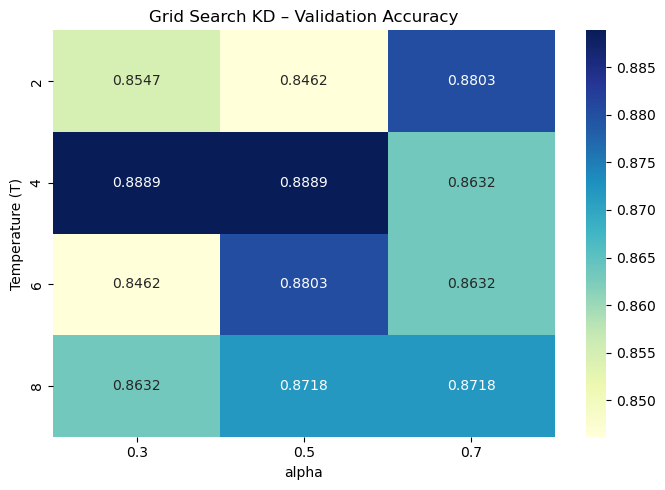

In [34]:
# Visualisasi heatmap hasil grid search
import pandas as pd

df_gs = pd.DataFrame(gs_results, columns=["T", "alpha", "val_acc"])
pivot  = df_gs.pivot(index="T", columns="alpha", values="val_acc")

plt.figure(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGnBu")
plt.title("Grid Search KD – Validation Accuracy")
plt.xlabel("alpha")
plt.ylabel("Temperature (T)")
plt.tight_layout()
plt.show()

## 8. Latih Student dengan Knowledge Distillation

In [35]:
def train_student_kd(root_dir, teacher_path, T, alpha,
                     save_path="checkpoints/student_kd_best.pth",
                     seed=SEED, max_epochs=100, early_stop=15):
    train_loader, val_loader, _ = get_dataloaders(root_dir, seed=seed)

    teacher = get_teacher().to(DEVICE)
    teacher.load_state_dict(torch.load(teacher_path, map_location=DEVICE))
    teacher.eval()

    student   = get_student().to(DEVICE)
    optimizer = Adam(student.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=5)

    best_val_loss    = float("inf")
    patience_counter = 0
    history          = {"val_loss": [], "val_acc": []}

    epoch_bar = tqdm(range(1, max_epochs + 1), desc=f"Student KD T={T} α={alpha}")
    for epoch in epoch_bar:
        # ── Train ──────────────────────────────────────────────────────────
        student.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with torch.no_grad():
                t_logits = teacher(imgs)
            s_logits = student(imgs)
            loss     = kd_loss(s_logits, t_logits, labels, T, alpha)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # ── Validation ─────────────────────────────────────────────────────
        student.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out       = student(imgs)
                val_loss += F.cross_entropy(out, labels).item()
                correct  += (out.argmax(1) == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc   = correct / len(val_loader.dataset)
        scheduler.step(val_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        epoch_bar.set_postfix(val_loss=f"{val_loss:.4f}", val_acc=f"{val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            torch.save(student.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= early_stop:
                print(f"\nEarly stopping pada epoch {epoch}")
                break

    print(f"\nBest val_loss : {best_val_loss:.4f}")
    print(f"Model disimpan: {save_path}")
    return history

Student KD T=4 α=0.3:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping pada epoch 40

Best val_loss : 0.3064
Model disimpan: checkpoints/student_kd_best.pth


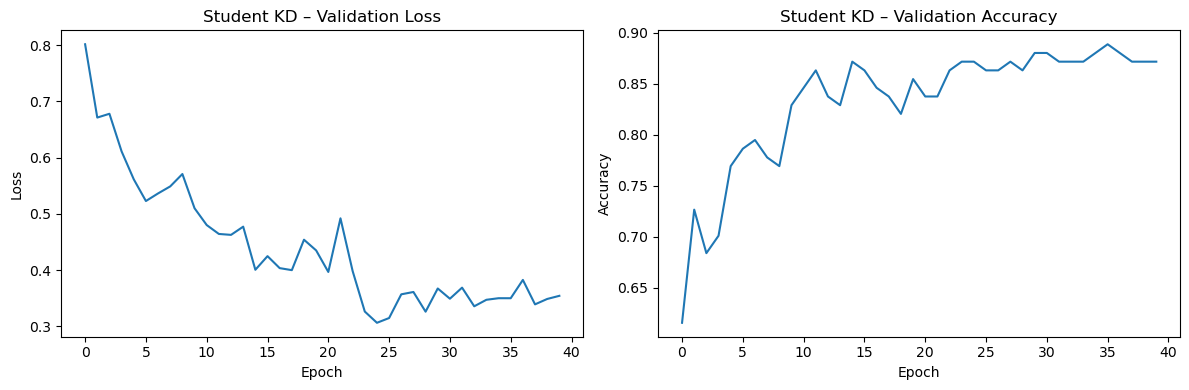

In [36]:
STUDENT_KD_PATH = "checkpoints/student_kd_best.pth"

history_student = train_student_kd(
    ROOT_DIR, TEACHER_PATH,
    T=best_T, alpha=best_alpha,
    save_path=STUDENT_KD_PATH
)

# Plot training history student
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_student["val_loss"])
ax1.set_title("Student KD – Validation Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax2.plot(history_student["val_acc"])
ax2.set_title("Student KD – Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
plt.tight_layout()
plt.show()

## 9. Evaluasi Model

### 9a. Efisiensi: Jumlah Parameter & Inference Time

In [37]:
def measure_inference_time(model, device, n_runs=100):
    dummy = torch.randn(1, 3, 224, 224).to(device)
    model.eval()
    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            t0 = time.perf_counter()
            model(dummy)
            times.append((time.perf_counter() - t0) * 1000)
    return np.mean(times[10:])   # buang 10 warm-up pertama


teacher_eval = get_teacher().to(DEVICE)
student_eval = get_student().to(DEVICE)

print(f"{'Model':<30} {'Params (M)':>12} {'Inference (ms)':>16}")
print("-" * 60)
print(f"{'Teacher (ResNet-50)':<30} {count_params(teacher_eval):>12.2f} {measure_inference_time(teacher_eval, DEVICE):>16.2f}")
print(f"{'Student (MobileNetV3-Sm.)':<30} {count_params(student_eval):>12.2f} {measure_inference_time(student_eval, DEVICE):>16.2f}")

Model                            Params (M)   Inference (ms)
------------------------------------------------------------
Teacher (ResNet-50)                   23.51             7.94
Student (MobileNetV3-Sm.)              1.52             3.97


### 9b. Metrik Klasifikasi pada Test Set

In [38]:
def evaluate_model(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs  = imgs.to(device)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)


def print_metrics(name, preds, labels):
    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average="macro", zero_division=0)
    rec  = recall_score(labels, preds, average="macro", zero_division=0)
    f1   = f1_score(labels, preds, average="macro", zero_division=0)
    print(f"\n{'='*45}")
    print(f"Model: {name}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    return acc, prec, rec, f1


# Evaluasi Teacher
teacher_eval.load_state_dict(torch.load(TEACHER_PATH, map_location=DEVICE))
t_preds, t_labels = evaluate_model(teacher_eval, test_loader, DEVICE)
print_metrics("Teacher (ResNet-50)", t_preds, t_labels)

# Evaluasi Student KD
student_eval.load_state_dict(torch.load(STUDENT_KD_PATH, map_location=DEVICE))
s_preds, s_labels = evaluate_model(student_eval, test_loader, DEVICE)
print_metrics("Student KD (MobileNetV3-Sm.)", s_preds, s_labels)


Model: Teacher (ResNet-50)
  Accuracy  : 0.7949
  Precision : 0.7650
  Recall    : 0.8218
  F1-Score  : 0.7828

Model: Student KD (MobileNetV3-Sm.)
  Accuracy  : 0.8205
  Precision : 0.8188
  Recall    : 0.8021
  F1-Score  : 0.8090


(0.8205128205128205, 0.8187830687830688, 0.8020690778755295, 0.809026369168357)

### 9c. Confusion Matrix

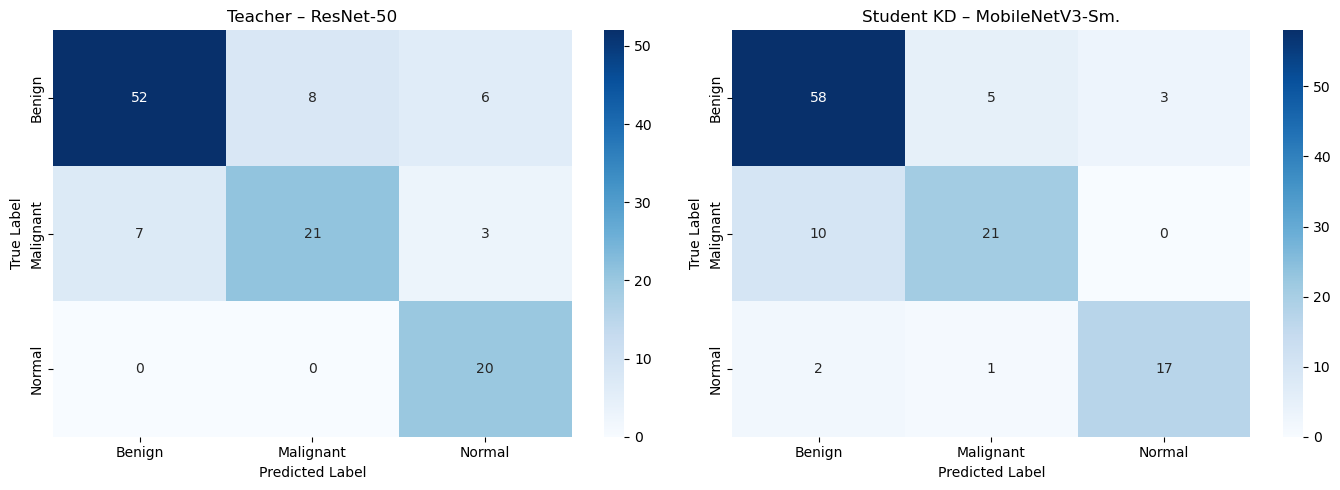

Confusion matrix disimpan: checkpoints/confusion_matrices.png


In [39]:
def plot_confusion_matrix(preds, labels, title, ax):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(title)
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_confusion_matrix(t_preds, t_labels, "Teacher – ResNet-50", axes[0])
plot_confusion_matrix(s_preds, s_labels, "Student KD – MobileNetV3-Sm.", axes[1])
plt.tight_layout()
plt.savefig("checkpoints/confusion_matrices.png", dpi=150)
plt.show()
print("Confusion matrix disimpan: checkpoints/confusion_matrices.png")

## 10. Reprodusibilitas Multi-Seed (Opsional)

Jalankan section ini untuk mengevaluasi performa di 5 seed berbeda dan melakukan uji statistik Wilcoxon.

In [ ]:
# ─── Latih Teacher & Student KD di semua seed ────────────────────────────────
# PERHATIAN: Proses ini membutuhkan waktu lama.
# Hapus komentar dan jalankan jika diperlukan untuk evaluasi multi-seed.

# for seed in SEEDS:
#     print(f"\n{'='*50}")
#     print(f"SEED = {seed}")
#     print(f"{'='*50}")
#
#     teacher_path = f"checkpoints/teacher_seed{seed}.pth"
#     if not os.path.exists(teacher_path):
#         train_teacher(ROOT_DIR, save_path=teacher_path, seed=seed)
#
#     student_path = f"checkpoints/student_kd_seed{seed}.pth"
#     if not os.path.exists(student_path):
#         train_student_kd(
#             ROOT_DIR, teacher_path,
#             T=best_T, alpha=best_alpha,
#             save_path=student_path,
#             seed=seed
#         )

print("Cell ini berisi kode multi-seed. Hapus komentar untuk menjalankannya.")

In [ ]:
def run_multi_seed_eval(model_fn, weight_path_template, loader, device):
    accs, precs, recs, f1s = [], [], [], []
    for seed in SEEDS:
        path = weight_path_template.format(seed)
        if not os.path.exists(path):
            print(f"[SKIP] {path} tidak ditemukan.")
            continue
        model = model_fn().to(device)
        model.load_state_dict(torch.load(path, map_location=device))
        preds, labels = evaluate_model(model, loader, device)
        accs.append(accuracy_score(labels, preds))
        precs.append(precision_score(labels, preds, average="macro", zero_division=0))
        recs.append(recall_score(labels, preds, average="macro", zero_division=0))
        f1s.append(f1_score(labels, preds, average="macro", zero_division=0))
    return (np.array(accs), np.array(precs),
            np.array(recs),  np.array(f1s))


def print_multi_metrics(name, accs, precs, recs, f1s):
    print(f"\n{'='*45}")
    print(f"Model: {name}")
    print(f"  Accuracy  : {accs.mean():.4f} ± {accs.std():.4f}")
    print(f"  Precision : {precs.mean():.4f} ± {precs.std():.4f}")
    print(f"  Recall    : {recs.mean():.4f} ± {recs.std():.4f}")
    print(f"  F1-Score  : {f1s.mean():.4f} ± {f1s.std():.4f}")


# ─── Evaluasi multi-seed (uncomment setelah semua checkpoint tersedia) ────────
# accs_t, precs_t, recs_t, f1s_t = run_multi_seed_eval(
#     get_teacher, "checkpoints/teacher_seed{}.pth", test_loader, DEVICE
# )
# accs_s, precs_s, recs_s, f1s_s = run_multi_seed_eval(
#     get_student, "checkpoints/student_kd_seed{}.pth", test_loader, DEVICE
# )
# print_multi_metrics("Teacher multi-seed", accs_t, precs_t, recs_t, f1s_t)
# print_multi_metrics("Student KD multi-seed", accs_s, precs_s, recs_s, f1s_s)

# ─── Uji Wilcoxon ─────────────────────────────────────────────────────────────
# stat, p = wilcoxon(f1s_t, f1s_s)
# print(f"\nWilcoxon Signed-Rank Test")
# print(f"  statistic = {stat:.4f}")
# print(f"  p-value   = {p:.4f}")
# if p < 0.05:
#     print("  → Perbedaan signifikan secara statistik (α=0.05)")
# else:
#     print("  → Perbedaan TIDAK signifikan secara statistik (α=0.05)")

print("Cell ini berisi kode evaluasi multi-seed. Hapus komentar setelah semua checkpoint siap.")